In [14]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay,accuracy_score,recall_score,f1_score,precision_score
from sklearn.preprocessing import StandardScaler

In [4]:
df=pd.read_csv("email_spam_dataset.csv")


In [5]:
#Feature and the target
#Note the number of emails here means how many email are sent
#in the chain of the single email, or how many recepents
#the same email was sent
X=df[["Num_Emails"]]
y=df["Spam"]

In [6]:
#Train-test split
#stratify=y means both training and test sets should have tge same split between spam(0 and non spam(1) 
#eg if non spam is 90% in training then it must be 90% in the test also
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=101,stratify=y)
print(f"Training samples:{len(X_train)}")
print(f"Testing samples:{len(X_test)}")

Training samples:800
Testing samples:200


In [7]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [10]:
#5 predict the probabilities and labels on test set
y_prob=model.predict_proba(X_test)[:,1] #probability that the spam =1
y_pred=(y_prob>=0.5).astype(int)
print(y_prob,y_pred)

[0.16482617 0.45507414 0.20416474 0.0785614  0.07129473 0.19577364
 0.10215155 0.43564042 0.27547093 0.10215155 0.18764609 0.3849237
 0.5595816  0.24519421 0.04238041 0.4420994  0.02133314 0.6765152
 0.29144946 0.5595816  0.31357867 0.14428849 0.55310788 0.20845943
 0.08244365 0.68222829 0.34840189 0.61668927 0.28606291 0.05576375
 0.02079236 0.06789863 0.61668927 0.41004295 0.21282032 0.08859484
 0.11482237 0.06625738 0.65906217 0.59792682 0.02079236 0.19577364
 0.0844496  0.39741575 0.03129492 0.22629989 0.04684868 0.73107554
 0.1508869  0.0844496  0.0785614  0.76560967 0.04924755 0.02974317
 0.42920321 0.6765152  0.14428849 0.62901092 0.30796088 0.05576375
 0.66493084 0.28606291 0.23561606 0.58525349 0.03736622 0.03832118
 0.55310788 0.26512549 0.28606291 0.03377031 0.1508869  0.1508869
 0.1070641  0.77489165 0.75606545 0.0844496  0.76560967 0.04345774
 0.42278986 0.5595816  0.57246633 0.11218338 0.0268604  0.0268604
 0.18764609 0.191677   0.04684868 0.73620078 0.08859484 0.70995652

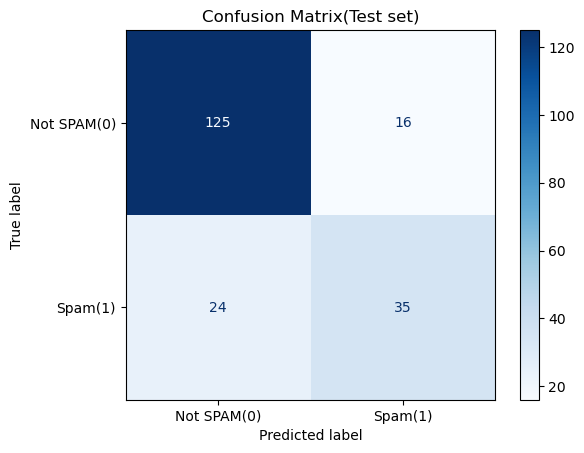

In [12]:
#6. Confusion matrix
cm=confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not SPAM(0)', 'Spam(1)'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix(Test set)")
plt.show()

In [15]:
#Evaluation Matrices
acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(acc,prec,rec,f1)

0.8 0.6862745098039216 0.5932203389830508 0.6363636363636364
